In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
import glob

hourly_input = "../DATA/rainfall/hourly_gauges_SIATA_EPM/"  
path_inventory = "../DATA/landslides/"
ONI_input = "../DATA/rainfall/ENSO/"

horas_reordenadas = list(range(6, 24)) + list(range(6))  # Reordenar para que empiece de 6 a 5

def normalize_to_percentage(values):
    return (values / values.sum()) * 100

def get_circle_size(value):
    if value == 0:
        return 0
    elif 1 <= value <= 5:
        return 50
    elif 6 <= value <= 10:
        return 150
    elif 11 <= value <= 20:
        return 250
    elif 21 <= value:
        return 400

def read_and_concat_files(file_paths, exclude_epm=False):
    if exclude_epm:
        file_paths = file_paths[:-16]
    
    data_frames = []
    for file in file_paths:
        station_data = pd.read_csv(file, index_col='Fecha', parse_dates=True, usecols=lambda col: 'Unnamed: 0' not in col)
        data_frames.append(station_data)
    
    return pd.concat(data_frames, axis=1)

oni_df = pd.read_excel(ONI_input + "/ONI.xlsx")

season_to_months = {
    'DJF': [12, 1, 2],
    'JFM': [1, 2, 3],
    'FMA': [2, 3, 4],
    'MAM': [3, 4, 5],
    'AMJ': [4, 5, 6],
    'MJJ': [5, 6, 7],
    'JJA': [6, 7, 8],
    'JAS': [7, 8, 9],
    'ASO': [8, 9, 10],
    'SON': [9, 10, 11],
    'OND': [10, 11, 12],
    'NDJ': [11, 12, 1]
}

monthly_oni = []

for _, row in oni_df.iterrows():
    year = row['Year']
    for season, months in season_to_months.items():
        for month in months:
            if season in row:
                month_data = {
                    'Year': year if month != 12 else year - 1,  # December should belong to the previous year
                    'Month': month,
                    'ONI': row[season]
                }
                monthly_oni.append(month_data)

monthly_oni_df = pd.DataFrame(monthly_oni)
monthly_oni_df['Fecha'] = pd.to_datetime(monthly_oni_df[['Year', 'Month']].assign(Day=1))
monthly_oni_df['ENSO'] = pd.cut(monthly_oni_df['ONI'], bins=[-np.inf, -0.5, 0.5, np.inf], labels=['La Niña', 'Neutral', 'El Niño'])


hourly_files = sorted(glob.glob(hourly_input + 'H_Datos_Procesados_Est_*.csv'))
stations_with_paths = [(int(file.split('_')[-1].split('.')[0]), file) for file in hourly_files]
stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])
hourly_files = [station[1] for station in stations_with_paths_sorted]

all_stations_df = read_and_concat_files(hourly_files, exclude_epm=True)
all_stations_df = all_stations_df[(all_stations_df.index >= '2010-01-01') & (all_stations_df.index <= '2023-12-31')]

all_stations_df.index = pd.to_datetime(all_stations_df.index)

additional_cols = pd.DataFrame({
    'Mes': all_stations_df.index.month,
    'Hora': all_stations_df.index.hour,
    'Year': all_stations_df.index.year,
    'ENSO': all_stations_df.index.map(lambda x: monthly_oni_df.loc[(monthly_oni_df['Year'] == x.year) & (monthly_oni_df['Month'] == x.month), 'ENSO'].values[0]),
    'Total_P': all_stations_df.filter(like='P').mean(axis=1)
}, index=all_stations_df.index)

all_stations_df = pd.concat([all_stations_df, additional_cols], axis=1)

enso_phases = ['El Niño', 'La Niña', 'Neutral']
enso_data = {}

for phase in enso_phases:
    enso_data[phase] = all_stations_df[all_stations_df['ENSO'] == phase].groupby(['Mes', 'Hora'])['Total_P'].mean().unstack(level='Hora').reindex(columns=horas_reordenadas)

landslides_df = pd.read_csv('../DATA/landslides/inventory_DAGRD.csv')
landslides_df['fecha_hora_evento'] = pd.to_datetime(landslides_df['fecha_hora_evento'], errors='coerce')
landslides_df['Mes'] = landslides_df['fecha_hora_evento'].dt.month
landslides_df['Year'] = landslides_df['fecha_hora_evento'].dt.year
landslides_df['Hora'] = landslides_df['fecha_hora_evento'].dt.hour

landslides_df = pd.merge(landslides_df, monthly_oni_df[['Year', 'Month', 'ENSO']], left_on=['Year', 'Mes'], right_on=['Year', 'Month'], how='left')

landslides_by_phase = {}

for phase in enso_phases:
    landslides_by_phase[phase] = (
        landslides_df[landslides_df['ENSO'] == phase].groupby(['Mes', 'Hora']).size().unstack(fill_value=0).reindex(columns=horas_reordenadas, fill_value=0)
    )
    
landslides_by_phase[phase] = (
    landslides_df[landslides_df['ENSO'] == phase]
    .groupby(['Mes', 'Hora']).size()
    .unstack(fill_value=0)
    .reindex(columns=horas_reordenadas, fill_value=0)
)

landslides_by_month = {}
for phase in enso_phases:
    monthly_counts = landslides_by_phase[phase].sum(axis=1)
    monthly_counts = monthly_counts.reindex(range(1, 13), fill_value=0)
    landslides_by_month[phase] = monthly_counts.values

rainfall_by_month = {}
for phase in enso_phases:
    monthly_rainfall = enso_data[phase].sum(axis=1) 
    rainfall_by_month[phase] = monthly_rainfall.values


monthly_rainfall = enso_data[phase].mean(axis=1)

landslides_by_hour = landslides_df.groupby('Hora').size()
landslides_by_hour = pd.Series(landslides_by_hour)
landslides_by_hour_reordenado = landslides_by_hour.reindex(horas_reordenadas)
landslides_by_hour = landslides_by_hour_reordenado
#landslides_by_hour = normalize_to_percentage(landslides_by_hour_reordenado)

rainfall_by_hour_series = all_stations_df.groupby('Hora')['Total_P'].mean()
rainfall_by_hour_series = rainfall_by_hour_series.reindex(horas_reordenadas, fill_value=0)
rainfall_by_hour = rainfall_by_hour_series.values

landslides_by_month = {}
rainfall_by_month = {}

for phase in enso_phases:
    monthly_slides = landslides_by_phase[phase].sum(axis=1)
    monthly_slides = monthly_slides.reindex(range(1,13), fill_value=0)
    landslides_by_month[phase] = monthly_slides.values
    
    monthly_rain = enso_data[phase].sum(axis=1)  # o .mean(axis=1)
    rainfall_by_month[phase] = monthly_rain.values

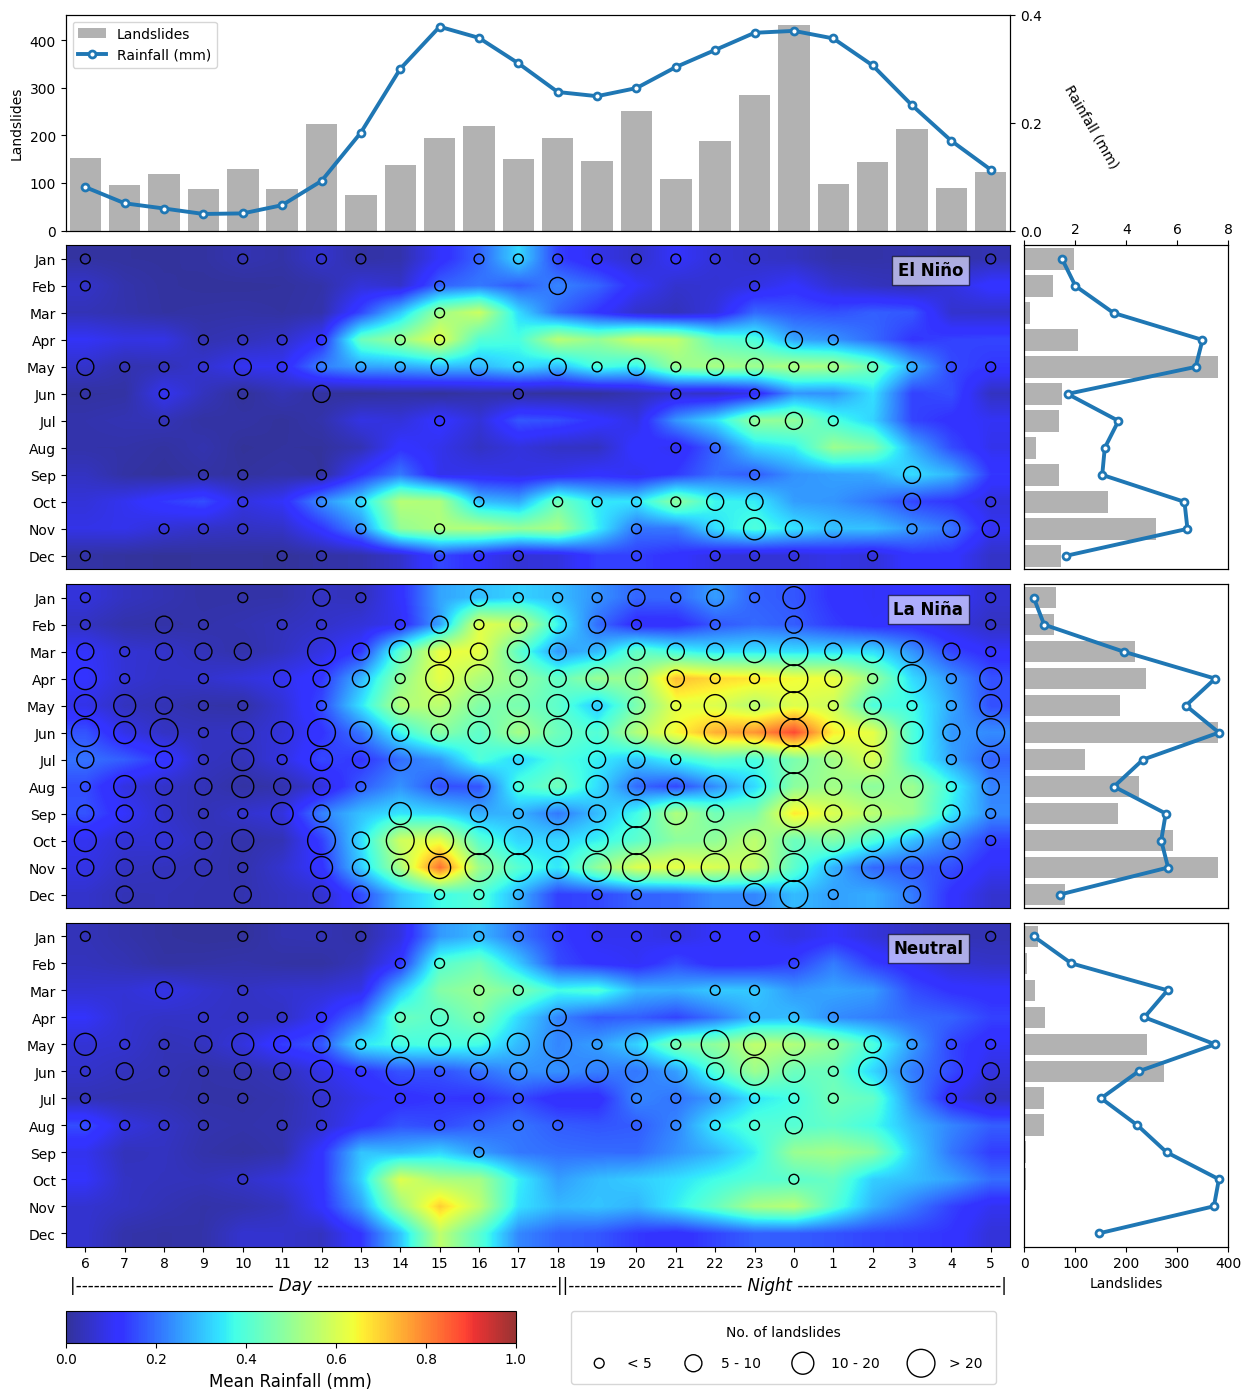

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

horas_reordenadas = list(range(6, 24)) + list(range(6))

x_pos = range(len(horas_reordenadas))


fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 4, 
                      height_ratios=[2, 3, 3, 3], 
                      width_ratios=[3, 3, 3, 2], 
                      hspace=0.05, 
                      wspace=0.05)

###############################################################################
# 1) Gráfico superior: barras de deslizamientos vs. línea de lluvia por hora  #
###############################################################################
ax_top = fig.add_subplot(gs[0, :3])
ax2 = ax_top.twinx()

ax2.plot(x_pos, rainfall_by_hour, 
         color="#1f77b4", marker='o', linestyle='-', linewidth=2.8,
         markerfacecolor='white', markeredgewidth=2, markersize=5, 
         label="Rainfall (mm)", zorder=2)
ax2.set_ylabel("Rainfall (mm)", color="black", fontsize=10, rotation=300, labelpad=40)
ax2.tick_params(axis='y', labelcolor="black")
ax2.set_yticks([0.0, 0.2, 0.4]) 

ax_top.bar(x_pos, landslides_by_hour, color="gray", alpha=0.6,
           width=0.8, label="Landslides", zorder=2)
ax_top.set_ylabel("Landslides", color="black", fontsize=10)
ax_top.tick_params(axis='y', labelcolor="black")
ax_top.set_yticks([0, 100, 200, 300, 400])
ax_top.set_xticks([]) 
ax_top.set_xticklabels([])

lines, labels = ax_top.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_top.legend(lines + lines2, 
              labels + labels2, 
              loc='upper left')

#ax_top.legend(loc="upper left")
#ax2.legend(loc="upper left", bbox_to_anchor=(0.0, -0.5))

ax_top.set_xlim(-0.5, len(horas_reordenadas) - 0.5)

###############################################################################
# 2) Subgráficos centrales (Matrices 12×24) para cada fase ENSO               #
###############################################################################
for i, phase in enumerate(enso_phases):
    ax = fig.add_subplot(gs[i + 1, :3])
    
    ax.text(0.95, 0.95, phase, transform=ax.transAxes, ha='right', va='top', 
            fontsize=12, weight='bold',
            bbox=dict(facecolor='white', alpha=0.6))
    
    data_matrix = enso_data[phase].values
    
    im = ax.imshow(data_matrix, cmap='jet', interpolation='bilinear', 
              aspect='auto', alpha=0.8, vmin=0, vmax=1)
    
    if i == 2:
        ax.set_xlabel('|--------------------------------- Day ----------------------------------------||----------------------------- Night ----------------------------------|', style ='italic', fontsize = 12)


    ax.set_yticks(range(12))
    ax.set_yticklabels([calendar.month_abbr[j] for j in range(1, 13)], fontsize=10)
    
    if i == len(enso_phases) - 1:
        ax.set_xticks(range(24))
        ax.set_xticklabels(horas_reordenadas, fontsize=10)
    else:
        ax.set_xticks([])

    total_months, total_hours = landslides_by_phase[phase].shape
    for m in range(total_months):
        for h in range(total_hours):
            val = landslides_by_phase[phase].iloc[m, h]
            circle_size = get_circle_size(val)
            if circle_size > 0:  # Solo agregar el círculo si hay deslizamientos
                ax.scatter(h, m, s=circle_size, facecolor='none', edgecolor='black', linewidth=1)
                
    

# Barra de color única para todas las fases
cax = fig.add_axes([0.125, 0.05, 0.3, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', fraction=0.07, pad=0.08)
cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_label('Mean Rainfall (mm)', fontsize=12)


###############################################################################
# 3) Subgráficos de barras mensuales (columnas de la derecha)                 #
###############################################################################
for i, phase in enumerate(enso_phases):
    ax = fig.add_subplot(gs[i + 1, 3])
    
    # Deslizamientos mensuales en el eje horizontal principal
    ax.barh(range(12), landslides_by_month[phase], 
            color='gray', alpha=0.6, label="Landslides")
    ax.set_yticks(range(12))
    ax.set_yticklabels([calendar.month_abbr[j] for j in range(1, 13)], fontsize=10)
    ax.invert_yaxis()

    # Eje secundario para lluvia mensual
    ax2 = ax.twiny()
    ax2.plot(rainfall_by_month[phase], range(12), 
             color='#1f77b4', marker='o', linestyle='-', linewidth=2.8,
             markerfacecolor='white', markeredgewidth=2, markersize=5,
             label="Rainfall (mm)")
    
    if i == 0:
        ax2.set_xlim(0, 8)
        ax2.set_xticks([0, 2, 4, 6, 8])
        ax2.set_xticklabels(["", "2", "4", "6", "8"])
    else:
        ax2.set_xticks([])
        ax2.set_xticklabels([])

    if i == 2:
        ax.set_xlabel("Landslides", fontsize=10)
        ax.set_xticks([0, 100, 200, 300, 400])
        ax.set_xticklabels([0, 100, 200, 300, 400])
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])



    #ax2.set_yticks([0.0, 0.2, 0.4])
    # Opcional: si quieres etiquetas de mes en este eje
    # ax.set_yticks(range(12))
    # ax.set_yticklabels([calendar.month_abbr[j] for j in range(1, 13)], fontsize=10)
    # ax.invert_yaxis()  # Si deseas enero arriba y diciembre abajo
    
    # Títulos en ejes
    # ax.set_xlabel("Landslides", fontsize=10)
    # ax2.set_xlabel("Rainfall (mm)", fontsize=10)
    # ax.legend(loc="lower right")
    # ax2.legend(loc="lower left")

      # Ajusta el rango del eje x derecho
    # Si no deseas ver ejes ni ticks aquí, déjalo así
    #ax.set_yticks([])
    #ax.set_yticklabels([])
    ax2.set_yticks([])
    ax2.set_yticklabels([])

    #ax.set_ylim(-0.5, len(range(12)) - 0.5)
    ax.set_ylim(len(range(12)) - 0.5, -0.5)




# Crear leyenda personalizada para los tamaños de los círculos
legend_labels = ['< 5', '5 - 10', '10 - 20', '> 20']
legend_sizes = [50, 150, 250, 400]

legend_circles = [
    plt.scatter([], [], s=size, facecolor='none', edgecolor='black', linewidth=1) 
    for size in legend_sizes
]

fig.legend(
    legend_circles,
    legend_labels,
    title="No. of landslides",
    loc='lower right',
    bbox_to_anchor=(0.75, 0.02),
    borderpad=1, 
    handletextpad=1, 
    labelspacing=1.2,
    ncol=4,
    fontsize=10
)

plt.savefig('../FIGURES/fig05.png', format='png', dpi=500, bbox_inches="tight")

plt.show()